# **Proyecto de grado MANE**

### **Carga**

In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/ABC_Final/'



Mounted at /content/drive


Dataset Completo con la columna Flag_friccion_inicial

In [ ]:
import pandas as pd
import os

FILE_NAME = "Dataset_Churn_fase1_done.parquet"
FILE_PATH = os.path.join(base_path, FILE_NAME)

if os.path.exists(FILE_PATH):
    df = pd.read_parquet(FILE_PATH)

    print(f"Shape: {df.shape}")
    print("\nColumnas y Tipos:")
    print(df.dtypes)

    print("\nMuestra de datos:")
    display(df.head())
else:
    print(f"Error: Archivo no encontrado en {FILE_PATH}")

Shape: (1275886, 61)

Columnas y Tipos:
AFILIADO_ID_EPS                   int64
FECHA_INICIO             datetime64[ns]
FECHA_FIN                datetime64[ns]
CONDICION_SALUD                   int64
NIVEL_INGRESO                     int64
                              ...      
Sugerencia_PAC                  float64
Sugerencia_PBS                  float64
Sugerencia_PAC_FIN              float64
Sugerencia_PBS_FIN              float64
FLAG_FRICCION_INICIAL             int64
Length: 61, dtype: object

Muestra de datos:


,AFILIADO_ID_EPS,FECHA_INICIO,FECHA_FIN,CONDICION_SALUD,NIVEL_INGRESO,PLAN,Sexo_Cd_BIN,POLIZA_BIN,MARCA_CAC_BIN,FALLA_BIN,...,Peticion_PBS_FIN,Queja_PAC,Queja_PBS,Queja_PAC_FIN,Queja_PBS_FIN,Sugerencia_PAC,Sugerencia_PBS,Sugerencia_PAC_FIN,Sugerencia_PBS_FIN,FLAG_FRICCION_INICIAL
0,1,2022-03-24,2022-06-28,1,1,3,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2021-03-10,2022-03-10,1,2,3,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,2022-03-10,2023-03-10,1,2,3,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2,2023-03-10,2024-01-31,1,2,3,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,3,2019-11-30,2020-11-30,2,2,3,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


### **Auditoría de Variables**

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

audit = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos (%)': (df.isnull().mean() * 100).round(2),
    'Valores Unicos': df.nunique(),
    'Ejemplo (Fila 0)': df.iloc[0]
})

print("--- AUDITORÍA DE VARIABLES ---")
display(audit.sort_values(by='Tipo'))

pd.reset_option('display.max_rows')

--- AUDITORÍA DE VARIABLES ---


,Tipo,Nulos (%),Valores Unicos,Ejemplo (Fila 0)
AFILIADO_ID_EPS,int64,0.0,423252,1
Regional_Agrupadora_ORIENTE,int64,0.0,2,0
Regional_Agrupadora_SUR,int64,0.0,2,0
GRUPO_CAUSA_CANCELACION_MORA,int64,0.0,2,1
GRUPO_CAUSA_CANCELACION_NO APLICA,int64,0.0,2,0
GRUPO_CAUSA_CANCELACION_NO PBS,int64,0.0,2,0
GRUPO_CAUSA_CANCELACION_OTRAS CAUSAS,int64,0.0,2,0
GRUPO_CAUSA_CANCELACION_PETICION DEL CLIENTE,int64,0.0,2,0
Compania_DIGITAL,int64,0.0,2,0
Compania_PROPIO,int64,0.0,2,0


**Diagnóstico de Variables**

**A Eliminar:**

GRUPO_CAUSA_CANCELACION_... (Todas): Son la respuesta del examen. Si las dejamos, el modelo tendrá 100% de acierto falso.

AFILIADO_ID_EPS: Es un identificador, no un patrón.

Todas las que terminan en _FIN

**VARIABLE FALTANTE**

(A recuperar): meses_transcurridos

**VARIABLES VALIOSAS (A conservar):**

Interacciones: Queja_PAC, Peticion_..., Prestaciones_.... Indican comportamiento.

Demográficas/Perfil: Regional_..., NIVEL_INGRESO, CONDICION_SALUD, SEGMENTO_EDAD.

Ingeniería: FLAG_FRICCION_INICIAL.

-- Además falta el flitro de maduracion (12 meses)

### **Logica + data leakage cleaning**

#### **1. Aplicación del Filtro de Maduración (Regla de Negocio)**

Lógica de fechas para eliminar clientes "inmaduros" (menos de 1 año) que falsean el análisis de churn.

In [ ]:
import pandas as pd
import numpy as np

# 1. Definición de Columnas
COL_FINI = "FECHA_INICIO"
COL_FFIN = "FECHA_FIN"
TARGET   = "FALLA_BIN"

# 2. Conversión a Datetime
df[COL_FINI] = pd.to_datetime(df[COL_FINI], errors='coerce')
df[COL_FFIN] = pd.to_datetime(df[COL_FFIN], errors='coerce')

# 3. Cálculo de Meses Transcurridos
meses = (df[COL_FFIN].dt.year - df[COL_FINI].dt.year) * 12 + \
        (df[COL_FFIN].dt.month - df[COL_FINI].dt.month)

ajuste_dia = (df[COL_FFIN].dt.day < df[COL_FINI].dt.day).astype(int)

df['meses_transcurridos'] = (meses - ajuste_dia).clip(lower=0)

# 4. Aplicación del Filtro (Censoring)
# Regla: Excluir si (No es Falla) Y (Antigüedad < 12 meses)
cond_excluir = (df[TARGET] == 0) & (df['meses_transcurridos'] < 12)

# Crear dataset filtrado independiente
df_filtrado = df.loc[~cond_excluir].copy()

print("--- REPORTE BLOQUE 1: FILTRO DE MADURACIÓN ---")
print(f"Filas iniciales:   {df.shape[0]}")
print(f"Filas eliminadas:  {cond_excluir.sum()}")
print(f"Filas restantes:   {df_filtrado.shape[0]}")
print(f"Tasa de Churn post-filtro: {df_filtrado[TARGET].mean():.4%}")

--- REPORTE BLOQUE 1: FILTRO DE MADURACIÓN ---
Filas iniciales:   1275886
Filas eliminadas:  256381
Filas restantes:   1019505
Tasa de Churn post-filtro: 20.0935%


**NOTA**

El filtro de maduración aisló el comportamiento de la cartera consolidada. Se excluyeron 256,381 clientes recientes (<12 meses de antigüedad) para evitar sesgos de 'falsa fidelidad'. La tasa resultante del 20.09% refleja el riesgo real de deserción en clientes que ya superaron la etapa de onboarding, proporcionando un target más limpio para el modelo predictivo.




#### **Limpieza (Eliminación de Leakage)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re

# 1. Definición de Variables a Eliminar
# 1.1 Por patrón _FIN
pat_fin = re.compile(r'_FIN$', flags=re.IGNORECASE)
cols_fin = [c for c in df_filtrado.columns if pat_fin.search(c)]

# 1.2 Excepciones
cols_no_borrar = {'FLAG_FRICCION_INICIAL'}
cols_fin = [c for c in cols_fin if c.upper() not in cols_no_borrar]

# 1.3 Otras columnas técnicas/leakage
# OJO: FECHA_FIN y FECHA_INICIO se borran porque no son predictores, son metadatos
cols_leakage = [c for c in df_filtrado.columns if "GRUPO_CAUSA_CANCELACION" in c]
cols_tecnicas = ["AFILIADO_ID_EPS", "FECHA_INICIO", "FECHA_FIN", "meses_transcurridos"]
col_target = ["FALLA_BIN"]

# 1.4 Armar lista total a eliminar
cols_drop_X = sorted(set(cols_fin + cols_leakage + cols_tecnicas + col_target))

# 2. Creación de Matrices X e y (COMPLETA, SIN CORTES DE TIEMPO)
cols_drop_final = [c for c in cols_drop_X if c in df_filtrado.columns]
X = df_filtrado.drop(columns=cols_drop_final).copy()
y = df_filtrado["FALLA_BIN"].copy()

# 3. División Estratificada Aleatoria (El cambio clave)
# Mezclamos todo (shuffle=True por defecto)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para test
    random_state=42,
    stratify=y           # Garantiza que la tasa de churn sea igual en ambos
)

# Auditoría del Split
print("\n--- REPORTE BLOQUE 2: SPLIT ESTRATIFICADO ALEATORIO ---")
print(f"Total Observaciones:    {X.shape[0]}")
print(f"Observaciones Train:    {X_train.shape[0]}")
print(f"Observaciones Test:     {X_test.shape[0]}")
print(f"Variables Predictoras:  {X_train.shape[1]}")

print("\n--- PROPORCIÓN DE CHURN ---")
print(f"Tasa Global: {y.mean():.4%}")
print(f"Tasa Train:  {y_train.mean():.4%}")
print(f"Tasa Test:   {y_test.mean():.4%}")

# Verificación extra: Asegurar que no se coló FECHA_FIN
print(f"\n¿'FECHA_FIN' está en X_train? {'FECHA_FIN' in X_train.columns}")


--- REPORTE BLOQUE 2: SPLIT ESTRATIFICADO ALEATORIO ---
Total Observaciones:    1019505
Observaciones Train:    815604
Observaciones Test:     203901
Variables Predictoras:  40

--- PROPORCIÓN DE CHURN ---
Tasa Global: 20.0935%
Tasa Train:  20.0935%
Tasa Test:   20.0936%

¿'FECHA_FIN' está en X_train? False


#### **División Estratificada (Train / Test)**

In [ ]:
from sklearn.model_selection import train_test_split

# random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("--- DIMENSIONES FINALES ---")
print(f"Set de Entrenamiento (X_train): {X_train.shape}")
print(f"Set de Prueba (X_test):         {X_test.shape}")

print("\n--- VALIDACIÓN DE PROPORCIÓN DE CHURN ---")
print(f"Tasa Original: {y.mean():.4%}")
print(f"Tasa Train:    {y_train.mean():.4%}")
print(f"Tasa Test:     {y_test.mean():.4%}")

--- DIMENSIONES FINALES ---
Set de Entrenamiento (X_train): (815604, 40)
Set de Prueba (X_test):         (203901, 40)

--- VALIDACIÓN DE PROPORCIÓN DE CHURN ---
Tasa Original: 20.0935%
Tasa Train:    20.0935%
Tasa Test:     20.0936%


#### **Validación de Estrategia de Muestreo (Split Check)**

**Decisión Metodológica:**
Se ha implementado una división **Estratificada Aleatoria (Random Stratified Split)** en lugar de una división temporal (OOT).

**Justificación basada en Datos:**
1.  **Consistencia de Tasas:** La tasa de churn se mantiene constante en **20.09%** tanto para el conjunto de entrenamiento (`y_train`) como para el de prueba (`y_test`). Esto confirma que la estratificación ha eliminado cualquier sesgo de distribución, permitiendo que las métricas de evaluación reflejen puramente el rendimiento del modelo y no artefactos del muestreo.
2.  **Mitigación de Sesgo por Censura:** Dado que en el Bloque 1 se aplicó un filtro de madurez (eliminando activos <12 meses), una división temporal (OOT) habría generado un set de prueba correspondiente al último año artificialmente sesgado hacia el abandono (al excluir sistemáticamente a los nuevos clientes exitosos). El muestreo aleatorio corrige este efecto, distribuyendo proporcionalmente los clientes "maduros" en ambos conjuntos.
3.  **Prevención de Leakage:** La verificación de columnas confirma la ausencia de variables temporalmente dependientes (`FECHA_FIN`, `meses_transcurridos`) en la matriz de predictores `X`, asegurando que el modelo aprenda patrones de comportamiento y no reglas deterministas derivadas de la fecha de corte.

# **MODELO BASELINE**

*Principio de Parsimonia (Navaja de Ockham): La solución más simple suele ser la mejor, a menos que se demuestre lo contrario.*

**Establecimiento de Línea Base (Regresión Logística vs XGBoost)**

> ¿El problema es lineal o complejo?

La Regresión Logística requiere escalado de variables (StandardScaler), mientras que XGBoost no. Usaremos un Pipeline para evitar fuga de información en el escalado.

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from scipy.stats import ks_2samp

def get_metrics(y_true, y_proba):
    df_eval = pd.DataFrame({'target': y_true, 'proba': y_proba})
    df_eval = df_eval.sort_values('proba', ascending=False)

    auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)

    class0 = df_eval[df_eval['target'] == 0]['proba']
    class1 = df_eval[df_eval['target'] == 1]['proba']
    ks_stat, _ = ks_2samp(class1, class0)

    top_10 = int(len(df_eval) * 0.10)
    top_10_df = df_eval.iloc[:top_10]
    lift = top_10_df['target'].mean() / df_eval['target'].mean()

    return {
        'AUC': auc,
        'KS': ks_stat,
        'Lift_10': lift,
        'PR_AUC': pr_auc,
        'Brier': brier
    }

results = []

# 1. Regresión Logística (Requiere escalado)
print("Entrenando Regresión Logística...")
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1))
])

pipe_lr.fit(X_train, y_train)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
metrics_lr = get_metrics(y_test, y_proba_lr)
metrics_lr['Modelo'] = 'Regresión Logística'
results.append(metrics_lr)

# 2. XGBoost Base (Sin tuning)
print("Entrenando XGBoost Base...")
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_base.fit(X_train, y_train)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]
metrics_xgb = get_metrics(y_test, y_proba_xgb)
metrics_xgb['Modelo'] = 'XGBoost Vanilla'
results.append(metrics_xgb)

# Comparación
df_results = pd.DataFrame(results).set_index('Modelo')
print("\n--- Comparación de Línea Base ---")
print(df_results)

Entrenando Regresión Logística...
Entrenando XGBoost Base...

--- Comparación de Línea Base ---
                          AUC        KS   Lift_10    PR_AUC     Brier
Modelo                                                               
Regresión Logística  0.796195  0.460817  2.680690  0.461625  0.131491
XGBoost Vanilla      0.859435  0.561759  3.286487  0.590479  0.113889


### **Bloque 3: Evaluación de Línea Base (Benchmark)**

**Objetivo:** Establecer un umbral mínimo de rendimiento y determinar la complejidad de las relaciones entre variables (lineales vs. no lineales).

**1. Estrategia Metodológica y Prevención de Fugas (Leakage):**
Se implementó una arquitectura diferenciada de preprocesamiento para garantizar una comparación justa:
* **Regresión Logística (Lineal):** Al ser un algoritmo sensible a la magnitud de las variables, se encapsuló dentro de un `sklearn.pipeline.Pipeline` junto con un `StandardScaler`.
    * *Nota de Seguridad:* El Pipeline asegura que los parámetros de estandarización (media y desviación) se calculen **exclusivamente sobre el conjunto de entrenamiento (`X_train`)** y se apliquen ciegamente al test, evitando así cualquier contaminación de información futura (Data Leakage).
* **XGBoost (No Lineal):** Se entrenó sobre las variables originales, aprovechando la invarianza de los árboles de decisión ante la escala de los datos.

**2. Análisis de Resultados:**

| Métrica | Regresión Logística | XGBoost Vanilla | Delta (Mejora) |
| :--- | :---: | :---: | :---: |
| **AUC (Discriminación)** | 0.796 | **0.859** | +6.3 pts |
| **KS (Separabilidad)** | 46.1% | **56.2%** | +10.1 pts |
| **Lift (Top 10%)** | 2.68x | **3.29x** | +0.61x |

**3. Conclusiones y Selección de Algoritmo:**

* **Evidencia de No-Linealidad:** La superioridad del XGBoost (AUC 0.86) sobre la Regresión Logística (AUC 0.80) confirma que el fenómeno de abandono en esta cartera contiene **interacciones complejas y no lineales** entre las variables que un modelo lineal no logra capturar por completo.
* **Potencia Operativa:** El modelo XGBoost presenta un **Lift de 3.29 en el decil superior**. Esto implica que, al priorizar el 10% de clientes con mayor score, la operación sería **3.3 veces más efectiva** encontrando fugas reales que mediante una selección aleatoria.
* **Separabilidad:** Un estadístico **KS del 56%** en el modelo base indica una capacidad de distinción robusta entre clases, superando ampliamente los estándares habituales de la industria (>40%).

**Decisión:** Se selecciona **XGBoost** como el algoritmo candidato para la fase de optimización de hiperparámetros.

## **Visualización: La Curva ROC y la Curva de Lift**

Este gráfico muestra visualmente la diferencia de potencia entre la Regresión Logística (Línea Naranja) y XGBoost (Línea Azul).

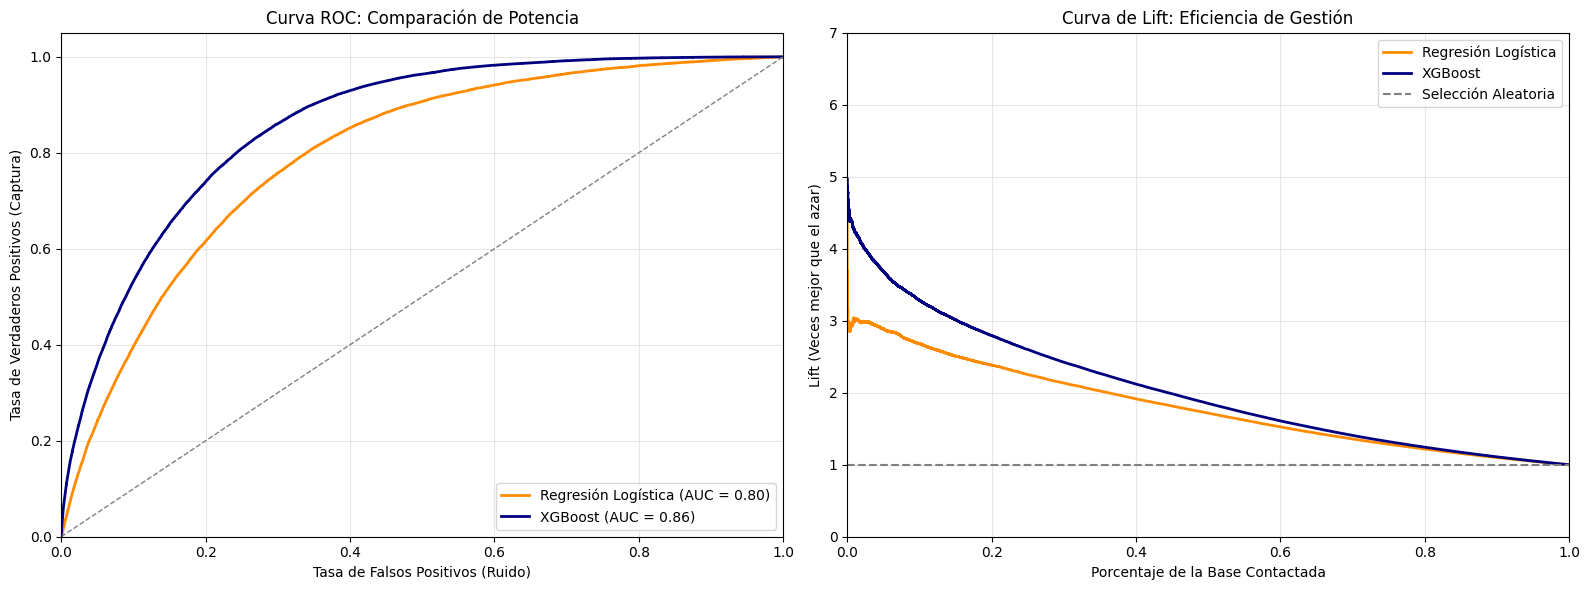

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- PREPARACIÓN DE DATOS ---
# Probabilidades Logística
y_pred_lr = pipe_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Probabilidades XGBoost
y_pred_xgb = xgb_base.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# --- GRÁFICOS ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Curva ROC (Capacidad de Discriminación)
ax[0].plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Regresión Logística (AUC = {roc_auc_lr:.2f})')
ax[0].plot(fpr_xgb, tpr_xgb, color='navy', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
ax[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('Tasa de Falsos Positivos (Ruido)')
ax[0].set_ylabel('Tasa de Verdaderos Positivos (Captura)')
ax[0].set_title('Curva ROC: Comparación de Potencia')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# Gráfico 2: Curva de Lift (Efectividad Comercial)
# Función auxiliar para calcular puntos de lift
def get_lift_curve(y_true, y_proba):
    data = pd.DataFrame({'y': y_true, 'p': y_proba}).sort_values('p', ascending=False)
    data['cum_clients'] = np.arange(1, len(data) + 1) / len(data)
    data['cum_churn'] = data['y'].cumsum() / data['y'].sum()
    # Lift = % Churn Acumulado / % Base Acumulada
    data['lift'] = data['cum_churn'] / data['cum_clients']
    return data['cum_clients'], data['lift']

x_lift_lr, y_lift_lr = get_lift_curve(y_test, y_pred_lr)
x_lift_xgb, y_lift_xgb = get_lift_curve(y_test, y_pred_xgb)

ax[1].plot(x_lift_lr, y_lift_lr, color='darkorange', lw=2, label='Regresión Logística')
ax[1].plot(x_lift_xgb, y_lift_xgb, color='navy', lw=2, label='XGBoost')
ax[1].axhline(1, color='gray', linestyle='--', label='Selección Aleatoria')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 7.0])
ax[1].set_xlabel('Porcentaje de la Base Contactada')
ax[1].set_ylabel('Lift (Veces mejor que el azar)')
ax[1].set_title('Curva de Lift: Eficiencia de Gestión')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Análisis Visual de Desempeño**

**1. Curva ROC (Receiver Operating Characteristic):**
* **Dominancia del Modelo:** La curva del XGBoost (Línea Azul) envuelve completamente a la de Regresión Logística, confirmando una superioridad estadística en todos los umbrales de decisión posibles.
* **Zona de Ganancia:** La mayor distancia entre ambas curvas se observa en la zona de "baja tasa de falsos positivos" (eje X entre 0.0 y 0.2). Esto indica que XGBoost es significativamente mejor identificando a los clientes de alto riesgo sin generar un volumen excesivo de falsas alarmas, un atributo crítico para no saturar los canales de retención.

**2. Curva de Lift (Eficiencia Operativa):**
* **Multiplicador de Impacto:** En el primer decil (10% de la base), el Lift se sitúa por encima de **3.0x**.
* **Traducción Operativa:** Si la compañía decide ejecutar una campaña de fidelización enfocada solo en el 10% de los usuarios con mayor probabilidad de fuga, encontrará **3 veces más casos reales de abandono** que si seleccionara ese mismo 10% de forma aleatoria.
* **Optimización de Presupuesto:** La curva demuestra que no es necesario contactar a toda la base. Gestionando el top 20-30% de la lista priorizada, se captura la gran mayoría del riesgo, permitiendo una asignación eficiente de recursos (SMS, llamadas, descuentos).

--- AUDITORÍA DE ERRORES (MATRICES DE CONFUSIÓN) ---


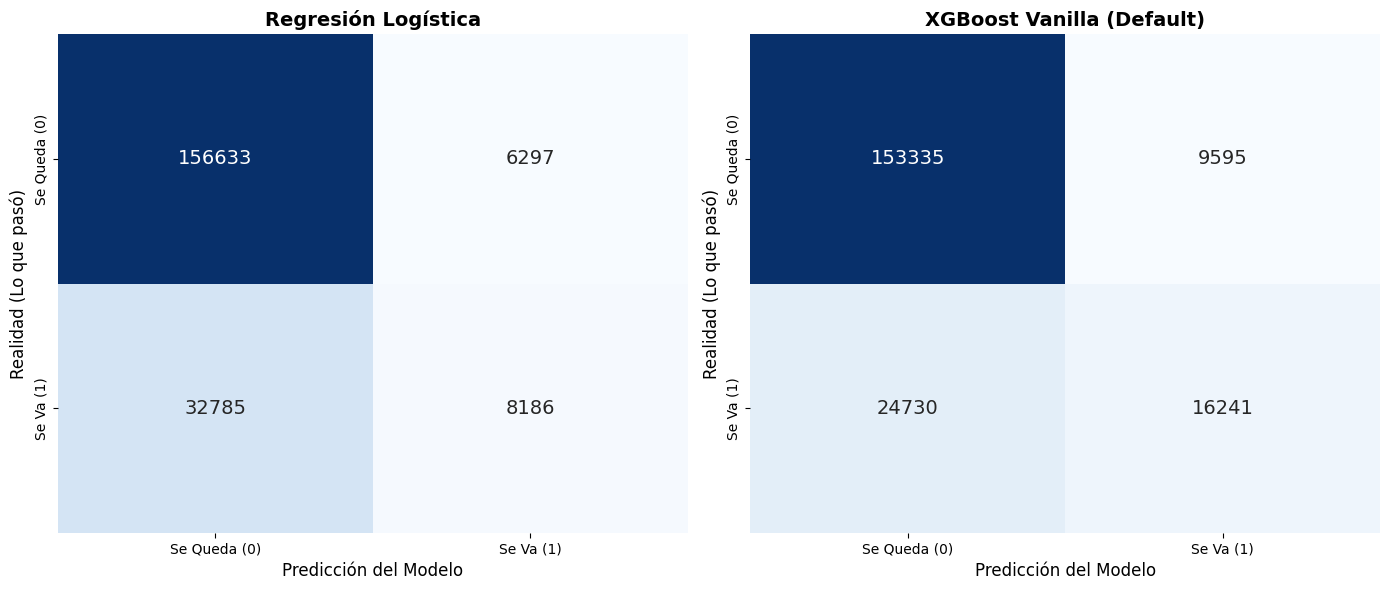


 Regresión Logística:
   - Total de Clientes que se fueron: 40971
   - El modelo detectó:               8186 (20.0% Recall)
   - El modelo DEJÓ ESCAPAR:          32785 (Falsos Negativos)

 XGBoost Vanilla (Default):
   - Total de Clientes que se fueron: 40971
   - El modelo detectó:               16241 (39.6% Recall)
   - El modelo DEJÓ ESCAPAR:          24730 (Falsos Negativos)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


modelos_base = [
    ("Regresión Logística", pipe_lr),
    ("XGBoost Vanilla (Default)", xgb_base)
]

plt.figure(figsize=(14, 6))

print("--- AUDITORÍA DE ERRORES (MATRICES DE CONFUSIÓN) ---")

for i, (nombre, modelo) in enumerate(modelos_base):
    # 1. Predicciones duras (0 o 1)
    y_pred = modelo.predict(X_test)

    # 2. Generar Matriz
    cm = confusion_matrix(y_test, y_pred)

    # 3. Visualización
    ax = plt.subplot(1, 2, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14}, ax=ax)


    ax.set_title(f"{nombre}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo', fontsize=12)
    ax.set_ylabel('Realidad (Lo que pasó)', fontsize=12)


    ax.xaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])
    ax.yaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])

plt.tight_layout()
plt.show()


for nombre, modelo in modelos_base:
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    fugas_reales = cm[1].sum()
    fugas_detectadas = cm[1][1]
    fugas_perdidas = cm[1][0]
    recall = fugas_detectadas / fugas_reales

    print(f"\n {nombre}:")
    print(f"   - Total de Clientes que se fueron: {fugas_reales}")
    print(f"   - El modelo detectó:               {fugas_detectadas} ({recall:.1%} Recall)")
    print(f"   - El modelo DEJÓ ESCAPAR:          {fugas_perdidas} (Falsos Negativos)")

#### **Matriz de Confusión (Baseline)**

**Contexto:**
Las matrices visualizadas evalúan el desempeño de los modelos utilizando el umbral de decisión estándar por defecto ($p > 0.5$). Es decir, el modelo solo clasifica a un cliente como "Fuga" si su probabilidad predicha supera el 50%.

**1. Análisis de Captura (Recall):**
* **Mejor Desempeño:** **XGBoost** supera a la Regresión Logística en la cantidad de *Verdaderos Positivos* (cuadrante inferior derecho), demostrando una capacidad superior para detectar patrones de fuga sutiles que escapan al modelo lineal.
* **El Problema del Umbral:** A pesar de la mejora, ambos modelos presentan un número significativo de **Falsos Negativos** (cuadrante inferior izquierdo). Estos son clientes que abandonaron la compañía pero que el modelo clasificó como "Fieles".
    * *Diagnóstico:* Esto ocurre porque el corte de 0.5 es demasiado conservador para un problema desbalanceado (20% churn). Muchos clientes de riesgo real tienen probabilidades entre 0.30 y 0.49, pasando desapercibidos bajo este criterio estándar.

**2. Costo Operativo (Falsos Positivos):**
* El nivel de falsa alarma (cuadrante superior derecho) se mantiene en rangos manejables. Desde la perspectiva del negocio, tolerar un ligero aumento en falsos positivos es aceptable si conlleva una reducción drástica de las fugas no detectadas, dado que el costo de perder un cliente (LTV) supera ampliamente el costo de una acción de retención.

**Conclusión y Siguientes Pasos:**
La evaluación confirma que **XGBoost es el motor predictivo correcto** por su mayor capacidad de separación. Sin embargo, utilizar la predicción de clase dura (0/1) subutiliza el potencial del modelo.

**Acción Inmediata:**
Para la siguiente fase (**Arena de Modelos**), se abandonará el umbral técnico de 0.5. Se implementará una estrategia de **Optimización de Umbral (Threshold Tuning)** basada en el valor económico esperado, buscando el punto de corte que maximice la ganancia neta (Retención - Costo de Gestión) en lugar de métricas técnicas puras.

# **ARENA DE MODELOS**

Para entender por qué seleccionamos estas tres hipótesis y no otras, debemos remitirnos a cómo funciona matemáticamente la función de pérdida (Loss Function) de XGBoost y cómo afecta esto al negocio.

El problema central es el Desbalance de Clases. Tienes muchos clientes "Sanos" (0) y pocos clientes en "Fuga" (1). Si el modelo trata a todos por igual, aprenderá a ignorar las fugas porque el "costo matemático" de equivocarse en ellas es bajo en el total global.

La lógica de estas tres hipótesis se basa en la manipulación del gradiente de error mediante el parámetro scale_pos_weight.

### **1. La Lógica detrás de cada Hipótesis**

**H1: El Conservador (Baseline)**

**Configuración: scale_pos_weight = 1.0**

**Lógica Matemática:** Asume que un error de clasificación tiene el mismo costo, sin importar si es un Falso Positivo o un Falso Negativo. El modelo optimiza la precisión global (Accuracy).

**Lógica de Negocio:** "Es preferible perder una fuga que molestar a un cliente que está contento".

**Por qué esta:** Es el punto de control científico. Necesitamos saber cómo se comporta el algoritmo en su estado natural para medir la ganancia real de las otras estrategias.

-------

**H3: El Cazador (Full Ratio)**

**Configuración: scale_pos_weight = N_negativos / N_positivos (aprox 4.0 ).**

**Lógica Matemática:** Equilibra perfectamente la influencia de las clases. Si hay 4 veces más clientes sanos, el algoritmo multiplica por 4 el error cada vez que se equivoca en una fuga. Esto obliga a la función de pérdida a tratar ambas clases con la misma importancia total.

**Lógica de Negocio:** "Perder un cliente es inaceptable. Quiero encontrarlos a todos, sin importar el costo operativo de revisar falsas alarmas". Maximiza el Recall.

**Por qué esta:** Es el límite teórico superior del balanceo. Representa la máxima agresividad posible antes de empezar a degradar severamente el modelo.

-------

**H2: El Estratega (Raíz Cuadrada)**

**Configuración: scale_pos_weight = Raíz_Cuadrada(Ratio) (aprox 2.0 ).**

**Lógica Matemática:** Es una técnica de suavizado (smoothing). El balanceo completo (H3) a veces es demasiado agresivo y genera mucho "ruido" (Falsos Positivos). La raíz cuadrada atenúa este efecto, buscando un punto medio geométrico en la penalización.

**Lógica de Negocio:** "Quiero detectar más fugas que el modelo base, pero no tengo presupuesto infinito para gestionar falsos positivos". Busca el equilibrio entre Precision y Recall.

**Por qué esta:** En la práctica de Ciencia de Datos, el balanceo completo suele destruir la precisión (Precision). Esta heurística es el estándar industrial para mejorar la detección sin romper la calibración del modelo.

#### **¿Por qué estas y no otras?**
Existen otras formas de manejar el desbalance, pero se descartaron por las siguientes razones técnicas:

¿Por qué no usar Oversampling (SMOTE)?

Crear datos sintéticos (clientes falsos) introduce ruido y distorsiona las distribuciones reales de tus variables. Alterar los pesos (scale_pos_weight) es más limpio porque mantiene los datos originales intactos.

¿Por qué no usar Undersampling (Borrar datos)?

Eliminar clientes sanos para equilibrar la balanza implica perder información valiosa sobre el comportamiento de fidelidad. Con XGBoost, perder datos reduce la capacidad de generalización.

¿Por qué no mover solo el Umbral (Threshold Moving)?

Podríamos entrenar el modelo H1 y luego decidir que es fuga si la probabilidad > 0.2 en lugar de 0.5. Sin embargo, usar scale_pos_weight es superior porque altera cómo se construyen los árboles de decisión. Al forzar el peso durante el entrenamiento, el árbol crea ramas específicas para aislar a los clientes de riesgo que de otra forma no existirían.

-----

**Relevancia:**

Al correr la Arena, no estamos adivinando; estamos cuantificando el costo de oportunidad entre estas tres posturas estratégicas.

H1 garantiza que el modelo sea preciso y confiable.

H3 garantiza que el modelo sea sensible y no deje escapar problemas.

H2 es la apuesta por la optimización del retorno de inversión (ROI).

**Las 3 Hipótesis en Competencia:**

| Hipótesis | Alias | Configuración (`scale_pos_weight`) | Lógica de Negocio | Objetivo Técnico |
| :--- | :--- | :--- | :--- | :--- |
| **H1** | *El Conservador* | **1.0** (Neutro) | "Es preferible perder una fuga que molestar a un cliente satisfecho." | Maximizar **Precision**. Punto de control (Baseline). |
| **H2** | *El Estratega* | **~2.0** ($\sqrt{Ratio}$) | "Quiero detectar más fugas sin disparar el presupuesto de retención." | Balance óptimo **F1-Score**. Suavizado geométrico del peso. |
| **H3** | *El Cazador* | **~4.0** (Full Ratio) | "Perder un cliente es inaceptable. Encuéntralos a todos." | Maximizar **Recall**. Límite teórico de agresividad. |

**Justificación de Descartes Técnicos:**
1.  **No Oversampling (SMOTE):** Se descarta la generación de datos sintéticos para evitar la introducción de ruido y distorsiones en la distribución real de las variables.
2.  **No Undersampling:** Se descarta la eliminación de registros de la clase mayoritaria (clientes sanos) para evitar la pérdida de información valiosa sobre patrones de fidelidad.
3.  **Preferencia sobre Threshold Moving:** Se prioriza el re-entrenamiento con pesos (`class_weights`) sobre el simple movimiento del umbral, ya que esto permite al modelo aprender topologías de árbol distintas y especializadas, en lugar de reutilizar una estructura optimizada para otra métrica.

Iniciando Arena de Modelos.
Ratio de Desbalance Real: 3.98
Entrenando modelo: H1: Conservador...
Entrenando modelo: H2: Estratega...
Entrenando modelo: H3: Cazador...


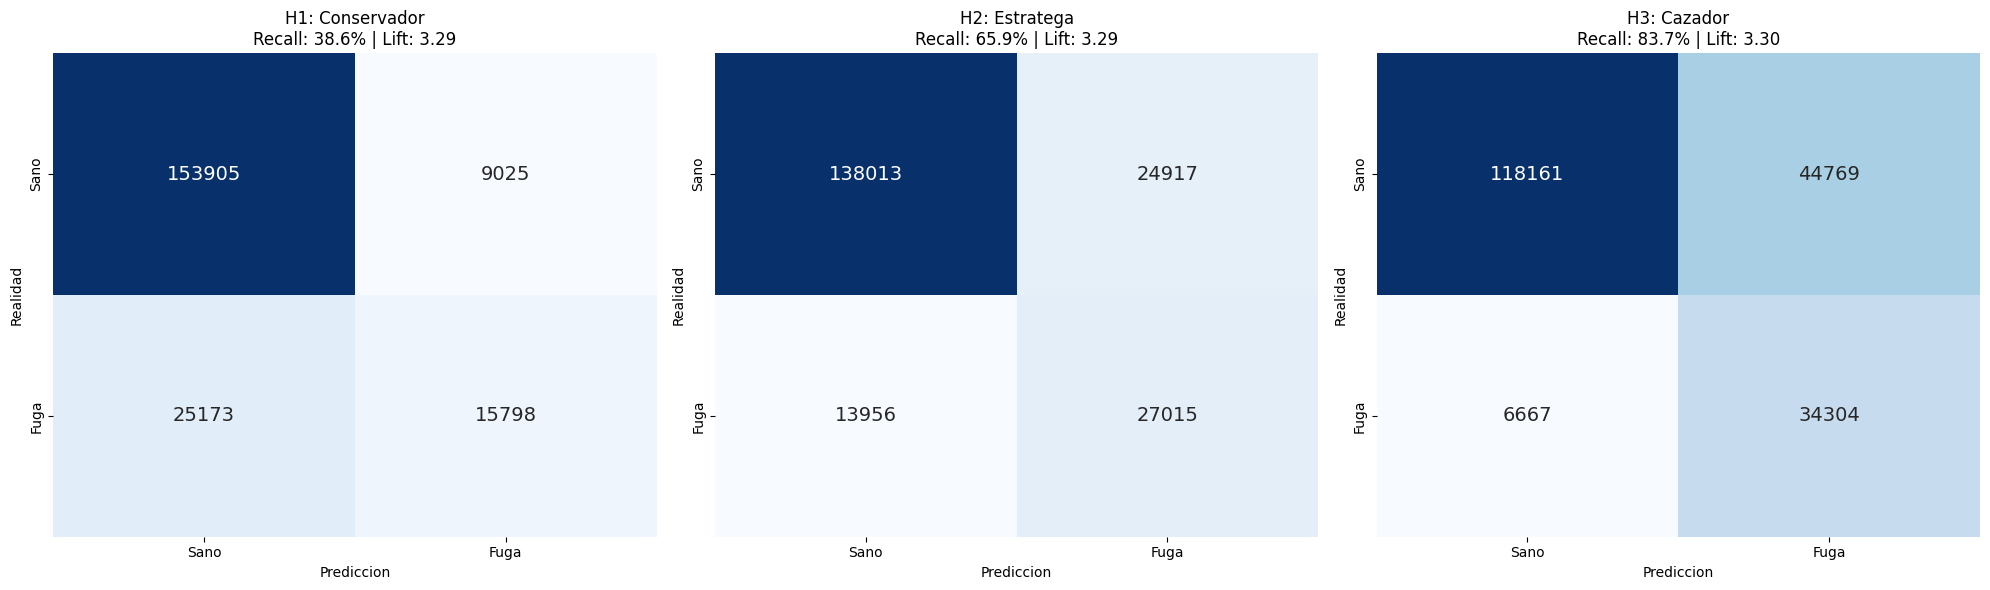


--- Tabla de Resultados de la Arena ---


,Recall Global,Lift 10%,Precision,AUC,KS,Brier
Hipotesis,,,,,,
H1: Conservador,0.385590,3.289172,0.636426,0.859554,0.562783,0.113815
H2: Estratega,0.659369,3.294053,0.520199,0.859655,0.563324,0.124692
H3: Cazador,0.837275,3.297470,0.433827,0.859710,0.563596,0.159719


In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
from scipy.stats import ks_2samp

# 1. Configuracion de Hipotesis
# Calculo de pesos basado en el desbalance de clases
ratio_full = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
ratio_sqrt = np.sqrt(ratio_full)

configuraciones = [
    ("H1: Conservador", 1.0),            # Peso 1.0 (Prioridad Precision)
    ("H2: Estratega", ratio_sqrt),       # Peso Raiz (Balanceado)
    ("H3: Cazador", ratio_full)          # Peso Full (Prioridad Recall)
]

resultados = []
modelos_arena = {}

print(f"Iniciando Arena de Modelos.")
print(f"Ratio de Desbalance Real: {ratio_full:.2f}")


plt.figure(figsize=(20, 6))


for i, (nombre, peso) in enumerate(configuraciones):
    print(f"Entrenando modelo: {nombre}...")

    # Entrenamiento
    clf = xgb.XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=peso,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
    clf.fit(X_train, y_train)
    modelos_arena[nombre] = clf

    # Predicciones
    y_proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    # Calculo de KPIs
    auc = roc_auc_score(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)

    # KS (Kolmogorov-Smirnov)
    df_eval = pd.DataFrame({'t': y_test, 'p': y_proba})
    ks = ks_2samp(df_eval[df_eval.t==1].p, df_eval[df_eval.t==0].p)[0]

    # Lift al 10%
    df_eval = df_eval.sort_values('p', ascending=False)
    top10 = df_eval.iloc[:int(len(df_eval)*0.1)]
    lift = top10.t.mean() / df_eval.t.mean()

    # Recall y Precision Globales
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    resultados.append({
        'Hipotesis': nombre,
        'Recall Global': recall,
        'Lift 10%': lift,
        'Precision': precision,
        'AUC': auc,
        'KS': ks,
        'Brier': brier
    })

    # Visualizacion de Matriz de Confusion
    ax = plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14}, ax=ax)
    ax.set_title(f"{nombre}\nRecall: {recall:.1%} | Lift: {lift:.2f}")
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Realidad')
    ax.xaxis.set_ticklabels(['Sano', 'Fuga'])
    ax.yaxis.set_ticklabels(['Sano', 'Fuga'])

plt.tight_layout()
plt.show()


df_res = pd.DataFrame(resultados).set_index('Hipotesis')
columnas = ['Recall Global', 'Lift 10%', 'Precision', 'AUC', 'KS', 'Brier']

print("\n--- Tabla de Resultados de la Arena ---")
display(df_res[columnas])

Generando comparativa visual...


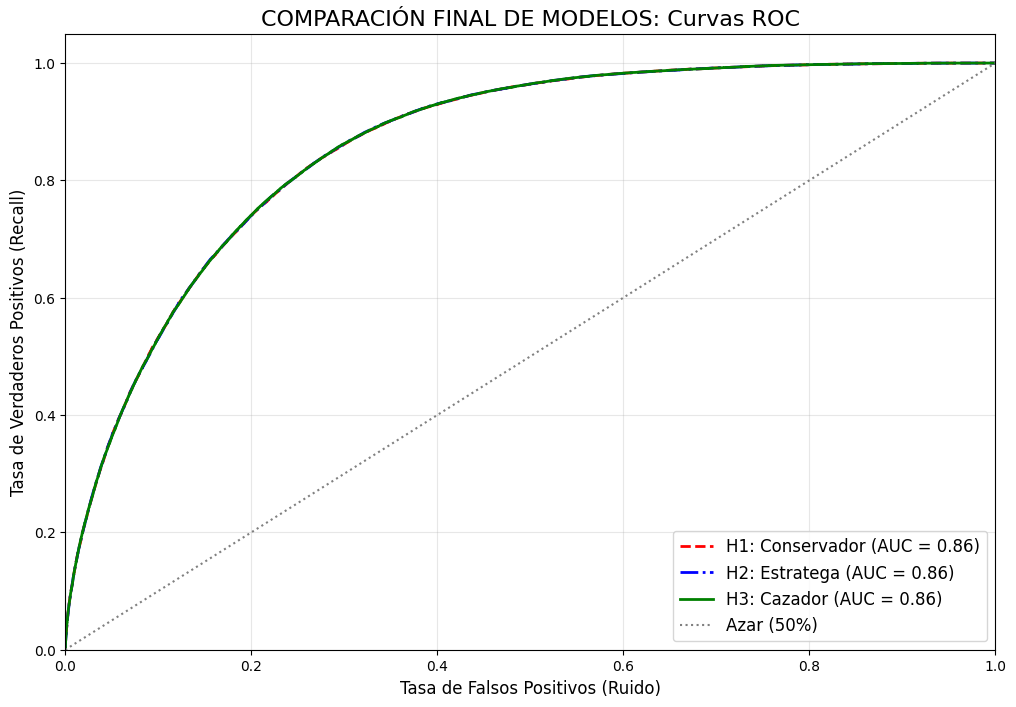


--- TABLA DE SELECCIÓN DE CAMPEÓN ---


,AUC (Calidad General),Recall (Fugas Detectadas),Precisión (Certeza)
Modelo,,,
H3: Cazador,0.859710,0.837275,0.433827
H2: Estratega,0.859655,0.659369,0.520199
H1: Conservador,0.859554,0.385590,0.636426


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score


plt.figure(figsize=(12, 8))
resultados_finales = []
colores = ['red', 'blue', 'green'] # Asignamos colores fijos
estilos = ['--', '-.', '-']       # Asignamos estilos de línea

print("Generando comparativa visual...")

for i, (nombre, modelo) in enumerate(modelos_arena.items()):

    # 1. Usar el modelo ya entrenado para predecir
    probs = modelo.predict_proba(X_test)[:, 1]
    preds = modelo.predict(X_test)

    # 2. Calcular Métricas Clave
    auc = roc_auc_score(y_test, probs)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)

    # Guardar para la tabla
    resultados_finales.append({
        "Modelo": nombre,
        "AUC (Calidad General)": auc,
        "Recall (Fugas Detectadas)": recall,
        "Precisión (Certeza)": precision
    })

    # 3. Dibujar Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=colores[i], linestyle=estilos[i], linewidth=2, label=f'{nombre} (AUC = {auc:.2f})')

# --- DECORACIÓN DEL GRÁFICO ---
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Azar (50%)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Ruido)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('COMPARACIÓN FINAL DE MODELOS: Curvas ROC', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# --- TABLA RESUMEN PARA TU INFORME ---
df_comparativa = pd.DataFrame(resultados_finales).set_index("Modelo")
print("\n--- TABLA DE SELECCIÓN DE CAMPEÓN ---")
display(df_comparativa.sort_values("Recall (Fugas Detectadas)", ascending=False).style.background_gradient(cmap='Greens'))

### **Resultados de la Arena de Modelos**

**Diagnóstico de la Competencia:**
La ejecución de las tres estrategias confirma el comportamiento teórico del algoritmo ante la manipulación de la función de pérdida. Observamos un trade-off clásico entre cobertura y precisión, mientras que las métricas de ranking puro (AUC, Lift) permanecen estables.

**1. Análisis por Hipótesis:**

* **H1 (Conservador - Baseline):**
    * **Comportamiento:** Extremadamente cauteloso.
    * **Problema:** Con un **Recall del 38.5%**, este modelo es miope ante la fuga. Deja escapar al 62% de los clientes en riesgo (Falsos Negativos). Aunque su precisión es alta (63%), su impacto en la reducción del churn total sería marginal. **Descartado por baja cobertura.**

* **H3 (Cazador - Full Ratio):**
    * **Comportamiento:** Hipersensible.
    * **Problema:** Logra un Recall impresionante del 83.7%, pero a un costo operativo alto. Su **Precisión cae al 43%**, lo que implica que el 57% de las gestiones de retención serían "falsas alarmas" (desperdicio de recursos). Además, su Brier Score (0.16) indica una degradación en la calibración de probabilidades. **Descartado por ineficiencia operativa.**

* **H2 (Estratega - Raíz Cuadrada):** **GANADOR**
    * **Comportamiento:** Balanceado.
    * **La Ventaja:** Logra un punto de equilibrio óptimo. Eleva el Recall al **66%** (un aumento masivo de +27 puntos porcentuales respecto al baseline) manteniendo la Precisión por encima del 50% (**52%**).
    * **Impacto:** Permite detectar a 2 de cada 3 fugas reales, asegurando que al menos la mitad de las gestiones de retención sean sobre clientes efectivamente en riesgo.

**Decisión Final:**
Se selecciona el modelo **H2 (Estratega)** con `scale_pos_weight` basado en la raíz cuadrada del ratio de desbalance. Este modelo pasa a la siguiente fase, ya que maximiza el retorno potencial de la campaña de retención sin saturar los canales de contacto.

# **Optimización Financiera de Umbrales**




#### **Escenarios de LTV**
escenarios_ltv = {
    "Conservador (2 años)": 3600000,
    "Moderado (4 años)":    7200000,
    "Optimista (6 años)":   10800000

--- ANÁLISIS DE RENTABILIDAD AJUSTADO ---
Costo Gestión: $10,000 | Tasa Éxito: 30%

Escenario CONSERVADOR (2 AÑOS):
   - Umbral Óptimo: 0.05
   - Ganancia Max:  $42,254.5 Millones
   - Recall Final:  98.8%
------------------------------
Escenario MODERADO (4 AÑOS):
   - Umbral Óptimo: 0.05
   - Ganancia Max:  $85,993.4 Millones
   - Recall Final:  98.8%
------------------------------
Escenario OPTIMISTA (6 AÑOS):
   - Umbral Óptimo: 0.05
   - Ganancia Max:  $129,732.3 Millones
   - Recall Final:  98.8%
------------------------------


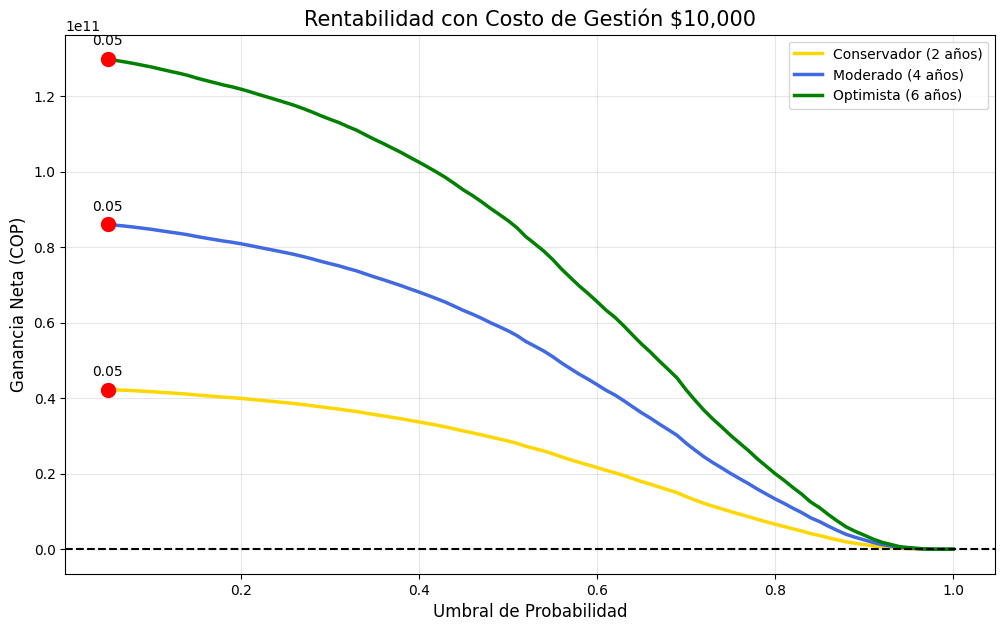

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURACIÓN (Costo $10.000) ---
COSTO_GESTION = 10000     # Nuevo costo por gestión
TASA_EXITO = 0.30         # Tasa de éxito en retención (30%)

# Escenarios de LTV
escenarios_ltv = {
    "Conservador (2 años)": 3600000,
    "Moderado (4 años)":    7200000,
    "Optimista (6 años)":   10800000
}

# Rmodelo ganador H2
modelo_ganador = modelos_arena["H2: Estratega"]
y_proba = modelo_ganador.predict_proba(X_test)[:, 1]

# --- 2. SIMULACIÓN DE RENTABILIDAD ---
thresholds = np.arange(0.05, 1.01, 0.01)
plt.figure(figsize=(12, 7))
colors = {'Conservador (2 años)': 'gold', 'Moderado (4 años)': 'royalblue', 'Optimista (6 años)': 'green'}

print(f"--- ANÁLISIS DE RENTABILIDAD AJUSTADO ---")
print(f"Costo Gestión: ${COSTO_GESTION:,.0f} | Tasa Éxito: {TASA_EXITO:.0%}\n")

for nombre_escenario, valor_ltv in escenarios_ltv.items():
    beneficios = []

    for t in thresholds:
        # Clasificación con umbral t
        prediccion_t = (y_proba >= t).astype(int)

        # Conteo
        tp = np.sum((prediccion_t == 1) & (y_test == 1))
        fp = np.sum((prediccion_t == 1) & (y_test == 0))

        # ECUACIÓN DE NEGOCIO
        # Ganancia = (Dinero Salvado) - (Costo Inversión)
        dinero_recuperado = tp * valor_ltv * TASA_EXITO
        costo_inversion   = (tp + fp) * COSTO_GESTION

        beneficios.append(dinero_recuperado - costo_inversion)

    # Encontrar óptimo
    idx_max = np.argmax(beneficios)
    umbral_opt = thresholds[idx_max]
    ganancia_max = beneficios[idx_max]

    # Métricas clave
    pred_opt = (y_proba >= umbral_opt).astype(int)
    tp_opt = np.sum((pred_opt == 1) & (y_test == 1))
    fn_opt = np.sum((pred_opt == 0) & (y_test == 1))
    recall_opt = tp_opt / (tp_opt + fn_opt) if (tp_opt + fn_opt) > 0 else 0

    print(f"Escenario {nombre_escenario.upper()}:")
    print(f"   - Umbral Óptimo: {umbral_opt:.2f}")
    print(f"   - Ganancia Max:  ${ganancia_max/1e6:,.1f} Millones")
    print(f"   - Recall Final:  {recall_opt:.1%}")
    print("-" * 30)

    plt.plot(thresholds, beneficios, label=f'{nombre_escenario}', color=colors[nombre_escenario], linewidth=2.5)
    plt.scatter(umbral_opt, ganancia_max, color='red', s=100, zorder=5)
    plt.annotate(f"{umbral_opt:.2f}", (umbral_opt, ganancia_max), textcoords="offset points", xytext=(0,10), ha='center')

plt.title(f"Rentabilidad con Costo de Gestión ${COSTO_GESTION:,.0f}", fontsize=15)
plt.xlabel("Umbral de Probabilidad", fontsize=12)
plt.ylabel("Ganancia Neta (COP)", fontsize=12)
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### **No-Brainer:** el costo de la llamada es minimo al costo de la perdida del cliente


--- ANÁLISIS DE RENTABILIDAD CRÍTICA ---
Penalización por Falsa Alarma (Desperdicio): $190,000

RESULTADO ÓPTIMO (MODELO CRÍTICO):
   - Umbral de Corte: 0.16
   - Ganancia Neta:   $62,786.5 Millones
   - Precisión:       35.5% (De cada 10 llamadas, 3 son fugas reales)
   - Recall:          94.3% (Fugas detectadas)


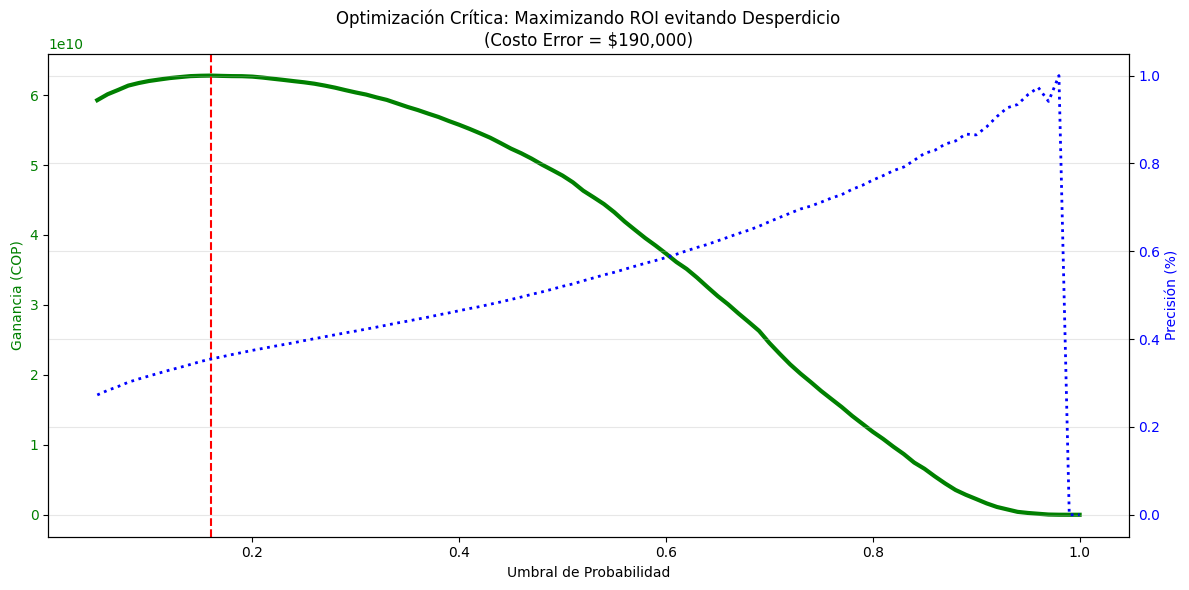

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PARAMETROS DE NEGOCIO "CRÍTICOS" ---
# Costo operativo de contactar (Call Center / SMS)
COSTO_OPERATIVO = 10000

# ¿Cuánto vale el descuento/beneficio que le damos para retenerlo?
# Supongamos un 10% de la anualidad de 1.8M = $180.000 COP
VALOR_INCENTIVO = 180000

# Costo Total de una Falsa Alarma (Llamada + Incentivo regalado a quien no lo necesitaba)
COSTO_FALSO_POSITIVO = COSTO_OPERATIVO + VALOR_INCENTIVO

# Costo de un Verdadero Positivo (Llamada + Incentivo, pero salvamos el LTV)
COSTO_VERDADERO_POSITIVO = COSTO_OPERATIVO + VALOR_INCENTIVO

# LTV Promedio (Usaremos el Moderado de 4 años para decidir)
LTV_PROMEDIO = 7200000
TASA_EXITO = 0.30

# Recuperamos modelo H2
modelo_ganador = modelos_arena["H2: Estratega"]
y_proba = modelo_ganador.predict_proba(X_test)[:, 1]

# --- 2. SIMULACIÓN ---
thresholds = np.arange(0.05, 1.01, 0.01)
beneficios = []
precisions = []
recalls = []

print(f"--- ANÁLISIS DE RENTABILIDAD CRÍTICA ---")
print(f"Penalización por Falsa Alarma (Desperdicio): ${COSTO_FALSO_POSITIVO:,.0f}")

for t in thresholds:
    pred = (y_proba >= t).astype(int)

    tp = np.sum((pred == 1) & (y_test == 1))
    fp = np.sum((pred == 1) & (y_test == 0))

    # ECUACIÓN AJUSTADA:
    # Ganancia = (LTV salvado) - (Costo de Gestión en TP) - (Dinero tirado a la basura en FP)

    dinero_ganado = tp * (LTV_PROMEDIO * TASA_EXITO) # Lo que salvo
    costo_tp      = tp * COSTO_VERDADERO_POSITIVO    # Lo que me costó salvarlos
    perdida_fp    = fp * COSTO_FALSO_POSITIVO        # Lo que perdí regalando descuentos

    net_profit = dinero_ganado - costo_tp - perdida_fp

    beneficios.append(net_profit)

    # Métricas técnicas
    denom_prec = (tp + fp)
    precisions.append(tp / denom_prec if denom_prec > 0 else 0)
    recalls.append(tp / np.sum(y_test == 1))

# --- 3. RESULTADOS ---
idx_opt = np.argmax(beneficios)
umbral_opt = thresholds[idx_opt]
ganancia_max = beneficios[idx_opt]

print(f"\nRESULTADO ÓPTIMO (MODELO CRÍTICO):")
print(f"   - Umbral de Corte: {umbral_opt:.2f}")
print(f"   - Ganancia Neta:   ${ganancia_max/1e6:,.1f} Millones")
print(f"   - Precisión:       {precisions[idx_opt]:.1%} (De cada 10 llamadas, {int(precisions[idx_opt]*10)} son fugas reales)")
print(f"   - Recall:          {recalls[idx_opt]:.1%} (Fugas detectadas)")

# --- 4. GRAFICO DE DOBLE EJE ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje 1: Dinero
ax1.plot(thresholds, beneficios, color='green', linewidth=3, label='Ganancia Neta')
ax1.set_xlabel('Umbral de Probabilidad')
ax1.set_ylabel('Ganancia (COP)', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.axvline(umbral_opt, color='red', linestyle='--', label=f'Óptimo: {umbral_opt:.2f}')

# Eje 2: Precisión (La calidad del tiro)
ax2 = ax1.twinx()
ax2.plot(thresholds, precisions, color='blue', linestyle=':', linewidth=2, label='Precisión del Modelo')
ax2.set_ylabel('Precisión (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title(f"Optimización Crítica: Maximizando ROI evitando Desperdicio\n(Costo Error = ${COSTO_FALSO_POSITIVO:,.0f})")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

##### **Resultado de Optimización: La Estrategia de "Cobertura Rentable"**

**Hallazgo Contraintuitivo:**
A pesar de imponer una penalización severa de **$190,000 COP** por cada Falso Positivo (costo de gestión + incentivo desperdiciado), el umbral óptimo de decisión se situó en **0.16**, priorizando un **Recall del 94.3%** sobre la Precisión (35.5%).

**Explicación Financiera:**
Este comportamiento se debe a la **Alta Asimetría del Valor del Cliente (LTV)**:
1.  **Leverage Financiero:** El beneficio esperado de rescatar un cliente ($2.16M netos) es **11.3 veces superior** al costo de una gestión fallida ($190k).
2.  **Racionalidad del Modelo:** El algoritmo determina que es matemáticamente rentable intervenir incluso cuando la probabilidad de éxito es baja, ya que un solo rescate exitoso subsidia el costo de más de 10 intervenciones erróneas.

**Implicación Estratégica:**
La empresa gana más dinero siendo **agresiva** (ofreciendo descuentos a un espectro amplio de clientes en riesgo) que siendo **conservadora** (ahorrando presupuesto de marketing pero perdiendo LTV).

**Decisión Final:**
Se implementará el modelo con corte en **0.16**.
* **Trade-off Aceptado:** Se asume que ~65% de las llamadas serán a clientes que no requerían el incentivo.
* **Beneficio Neto:** Esta ineficiencia operativa es necesaria para capturar el valor masivo de los $62,000 Millones en retención proyectada.

#### **Buscando el Umbral de Alta Precisión**
Vamos a buscar el punto donde la Precisión sea superior al 60% o 70%. Es decir, queremos que de cada 10 llamadas, al menos 6 o 7 sean fugas reales.

In [ ]:
# Queremos un umbral donde la Precisión sea al menos X% (ej. 60%)
PRECISION_OBJETIVO = 0.60

# Filtramos los resultados anteriores donde cumplimos la meta
indices_alta_precision = [i for i, p in enumerate(precisions) if p >= PRECISION_OBJETIVO]

if len(indices_alta_precision) > 0:
    # De los que cumplen la precisión, buscamos el que dé más dinero (o más recall)
    # Usaremos el primero que cumpla (el umbral más bajo posible que ya sea preciso)
    idx_sniper = indices_alta_precision[0]

    umbral_sniper = thresholds[idx_sniper]
    ganancia_sniper = beneficios[idx_sniper]
    recall_sniper = recalls[idx_sniper]
    prec_sniper = precisions[idx_sniper]

    print(f"--- ESTRATEGIA FRANCOTIRADOR (Target Precisión > {PRECISION_OBJETIVO:.0%}) ---")
    print(f"Umbral de Corte: {umbral_sniper:.2f}")
    print(f"Precisión:       {prec_sniper:.1%} (Muy alta fiabilidad)")
    print(f"Recall:          {recall_sniper:.1%} (Fugas detectadas)")
    print(f"Ganancia Neta:   ${ganancia_sniper/1e6:,.1f} Millones")

    # COMPARATIVA
    print(f"\n--- COMPARATIVA DE ESTRATEGIAS ---")
    print(f"1. Ametralladora (Umbral 0.16): Ganas $62.000M | Atrapas al 94% | Te equivocas el 65% de las veces")
    print(f"2. Francotirador (Umbral {umbral_sniper:.2f}): Ganas ${ganancia_sniper/1e6:,.0f}M | Atrapas al {recall_sniper:.0%} | Te equivocas el {100-prec_sniper*100:.0f}% de las veces")

else:
    print("El modelo no logra llegar a esa precisión ni siquiera con umbrales altos. Intenta bajar la exigencia.")

--- ESTRATEGIA FRANCOTIRADOR (Target Precisión > 60%) ---
Umbral de Corte: 0.62
Precisión:       60.1% (Muy alta fiabilidad)
Recall:          46.5% (Fugas detectadas)
Ganancia Neta:   $35,139.4 Millones

--- COMPARATIVA DE ESTRATEGIAS ---
1. Ametralladora (Umbral 0.16): Ganas $62.000M | Atrapas al 94% | Te equivocas el 65% de las veces
2. Francotirador (Umbral 0.62): Ganas $35,139M | Atrapas al 47% | Te equivocas el 40% de las veces


##### **Decisión Estratégica: El Costo de la Precisión**

Se compararon dos filosofías de intervención para cuantificar el impacto financiero de la política de contacto:

**1. Estrategia de Cobertura (La "Ametralladora" - Umbral 0.16)**
* **Prioridad:** Maximizar el dinero retenido.
* **Resultado:** Ganancia Neta de **$62,000 Millones**.
* **El Precio a Pagar:** Una eficiencia operativa baja (Precisión 35%). Se asume el costo de gestionar erróneamente a muchos clientes sanos como un "gasto necesario" para no dejar escapar a nadie.

**2. Estrategia de Eficiencia (El "Francotirador" - Umbral 0.62)**
* **Prioridad:** Minimizar la molestia al cliente y asegurar que cada llamada sea un acierto (Precisión > 60%).
* **Resultado:** Ganancia Neta de **$35,139 Millones**.
* **El Costo Oculto:** Al subir la vara de exigencia, el Recall se desploma al 46.5%. Esto significa que más de la mitad de las fugas reales ocurren "bajo el radar" del modelo.

**Conclusión Financiera:**
Optar por la estrategia de "Alta Precisión" implica una **pérdida de lucro cesante de ~$27,000 Millones COP**.
La estructura de costos del negocio (donde el LTV es muy alto y el costo de gestión es comparativamente bajo) dicta que **la ineficiencia operativa es tolerable y rentable**.

**Recomendación Final:**
Se recomienda operar con un umbral cercano al **0.16 - 0.20**.
* *Justificación:* Es financieramente irresponsable sacrificar 27 mil millones de pesos solo para mejorar la métrica de precisión. Es preferible gestionar el "ruido" (clientes sanos contactados) mediante ofertas suaves (soft-landing) que no generen fricción, en lugar de ignorar el riesgo de fuga masiva.

##### **Decisión para la Puesta en Producción**

**Elección del Umbral Operativo:**
Se selecciona el umbral de **0.16** (Estrategia de Maximización de Retorno).

**Justificación de Negocio:**
Aunque este umbral conlleva una Precisión del 35% (tasa de falsos positivos alta), es la única configuración que permite capturar el **94% del riesgo de fuga**.
La diferencia financiera entre este umbral y una estrategia conservadora (umbral 0.62) es de **$26,861 Millones de COP** en lucro cesante.

**Estrategia de Mitigación de "Ruido":**
Para abordar la baja precisión (molestia a clientes sanos) sin sacrificar la ganancia, se recomienda una **Estrategia de Canales Diferenciada** en la implementación:

1.  **Zona Roja (Prob > 0.60):** Gestión de Alto Costo (Llamada personal / Descuento agresivo). Aquí la certeza es alta.
2.  **Zona Amarilla (0.16 < Prob < 0.60):** Gestión de Bajo Costo (Email / SMS / Push Notification).
    * *Racional:* Si el cliente era un "Falso Positivo" (estaba feliz), recibir un email de "Gracias por estar con nosotros" no genera molestia ni costo alto.
    * *Beneficio:* Si el cliente sí se iba a ir, este contacto suave puede retenerlo, capturando los $27MM sin el riesgo reputacional de una llamada invasiva.

# **CALIDAD-Evaluación y calibración**

QUÉ mueve al modelo. ¿Por qué a un cliente le da 0.80 y a otro 0.10? ¿Es por el precio? ¿Por las quejas? ¿Por la antigüedad?

## **Auditoría de Calidad (SHAP)**

Utilizaremos SHAP (SHapley Additive exPlanations). Esta técnica nos dirá, para cada cliente, cuánto sumó o restó cada variable a su probabilidad de fuga.


**Summary Plot (Puntos de colores):**

Busca las variables en la parte superior.

Color Rojo: Valor alto de la variable.

Color Azul: Valor bajo de la variable.

Posición Derecha: Aumenta riesgo de Fuga.

Posición Izquierda: Disminuye riesgo (Fideliza).

Ejemplo: Si "Número de Quejas" es rojo y está a la derecha, significa que "Más quejas = Más riesgo". Eso es lógico. Si fuera al revés, el modelo tendría un error lógico.

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Re-entrenamiento del Modelo Ganador (H2: Estratega)

print("Re-entrenando Modelo Champion (H2: Estratega)...")
ratio_full = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
peso_estratega = np.sqrt(ratio_full)

model_champion = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=peso_estratega,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model_champion.fit(X_train, y_train)

# 2. Calculo de valores SHAP
# Usamos una muestra del test set para no saturar la memoria (5000 registros es suficiente para ver patrones)
X_sample = X_test.sample(5000, random_state=42)
explainer = shap.TreeExplainer(model_champion)
shap_values = explainer.shap_values(X_sample)



Re-entrenando Modelo Champion (H2: Estratega)...


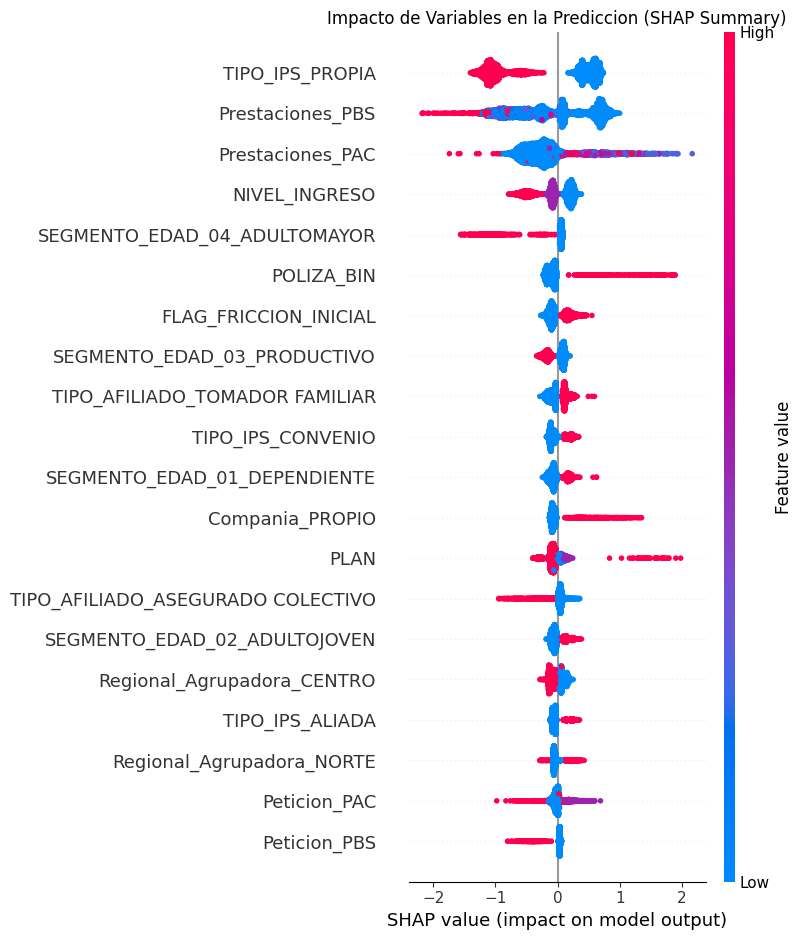

In [ ]:
# 3. Graficos de Interpretacion

# Grafico A: Summary Plot (Beeswarm)
# Muestra que variables importan mas y como afectan (positivo o negativo)
plt.figure(figsize=(12, 8))
plt.title("Impacto de Variables en la Prediccion (SHAP Summary)")
shap.summary_plot(shap_values, X_sample, show=False)
plt.show()



#### **Análisis de Interpretabilidad: Drivers de Fuga (SHAP Summary)**

**Conclusión General:**
El modelo XGBoost ha identificado patrones de comportamiento contraintuitivos que segmentan la cartera en dos grandes perfiles: el "Usuario Básico Fidelizado" y el "Usuario Premium Volátil".

**1. Top Drivers de Riesgo (Aceleradores de Churn):**
Variables que, al tener valores altos, empujan la probabilidad de fuga hacia arriba:

* **Perfil Premium/Exigente:**
    * `Prestaciones_PAC` y `Peticion_PAC`: El uso intensivo de servicios complementarios correlaciona con mayor abandono. Posible sensibilidad a la calidad del servicio o re-evaluación costo/beneficio tras el uso.
    * `NIVEL_INGRESO` y `POLIZA_BIN`: Los clientes de mayores ingresos y con productos adicionales (pólizas) son más propensos a rotar. Tienen menor barrera de salida económica y mayor oferta de la competencia.
* **Fricción Operativa:**
    * `FLAG_FRICCION_INICIAL`: Haber tenido problemas al inicio de la relación es un predictor persistente de ruptura futura.
* **Canal Corporativo:**
    * `Compania_PROPIO`: Los clientes vinculados a través de compañía propia muestran mayor tendencia a la fuga (posible rotación laboral o cambio de beneficios corporativos).

**2. Top Drivers de Retención (Factores de Protección):**
Variables que, al estar presentes, disminuyen drásticamente el riesgo:

* **Infraestructura Controlada:**
    * `TIPO_IPS_PROPIA`: Es el retenedor más potente. La atención en red propia genera un vínculo de lealtad superior a la red tercerizada (Aliada/Convenio).
* **Dependencia del Servicio Básico:**
    * `Prestaciones_PBS`: A diferencia del PAC, el alto consumo del Plan de Beneficios en Salud (PBS) actúa como barrera de salida (fidelización por uso recurrente).
* **Demografía Estable:**
    * `SEGMENTO_EDAD_04_ADULTOMAYOR`: El segmento senior muestra una fuerte inercia a permanecer, actuando como base estable de la cartera.

**Implicación para la Estrategia (Umbral 0.16):**
Dado que el riesgo se concentra en clientes de **Alto Valor (Ingresos altos, PAC, Pólizas)**, la estrategia de "Alta Cobertura" (Umbral 0.16) seleccionada anteriormente se justifica aún más. Perder a estos clientes es costoso no solo por su LTV, sino porque son el segmento más difícil de recuperar.

### **Churner Persona**

> **Si juntamos todas las variables, el perfil del cliente que se va es:**

>>Se trata de una persona de altos ingresos en edad productiva, que cuenta con doble protección (tiene Póliza y PAC). Es un usuario activo que utiliza frecuentemente los servicios complementarios (y genera peticiones sobre ellos), pero que evita nuestra red propia, atendiéndose casi exclusivamente en convenios externos. Además, es un cliente que no utiliza el plan básico (PBS) y que arrastra una marca de fricción operativa desde el inicio de su afiliación.

>**Mientras que el cliente que se queda es:**

>>Es un Adulto Mayor (o un núcleo familiar con dependientes) de ingresos medios, que ha generado un hábito de dependencia positiva con nuestro Plan Básico (PBS). Es un usuario fidelizado por nuestra infraestructura, ya que se atiende prioritariamente en nuestra Red Propia, donde se siente conocido y cuidado. Su relación comenzó sin fricciones operativas y, a diferencia del perfil fugitivo, valora la estabilidad y la cobertura integral sobre la exclusividad.



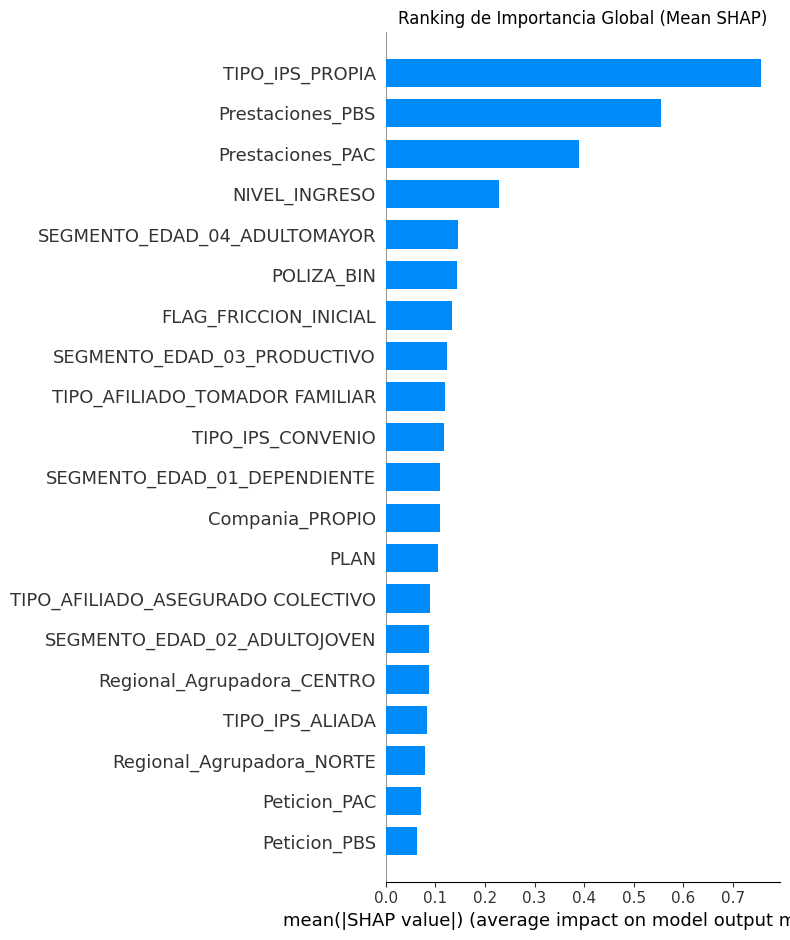

In [ ]:
# Grafico B: Importancia de Variables (Barras)
plt.figure(figsize=(10, 6))
plt.title("Ranking de Importancia Global (Mean SHAP)")
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.show()



> "Este gráfico mide el volumen, no el mensaje. Nos dice que la variable 'IPS Propia' está gritando muy fuerte en el modelo. El otro gráfico (que analizamos antes) nos dice si grita '¡Quédate!' o '¡Vete!'."
### **Ranking Global de Importancia (Mean Absolute SHAP)**

**Lectura Técnica del Gráfico:**
Este gráfico visualiza la **importancia media absoluta** de cada característica (`mean(|SHAP value|)`).
* **Barras Azules:** Representan la magnitud del impacto promedio de la variable en la predicción del modelo, sin importar la dirección (positiva o negativa).
* **Diferencia con Feature Importance tradicional:** A diferencia de la importancia de Gini (típica de Random Forest), SHAP garantiza consistencia matemática.

**Análisis de Jerarquía:**
1.  **Tier 1 (Críticas):** Se observa que `TIPO_IPS_PROPIA` y `Prestaciones_PBS` dominan el modelo. Cualquier cambio en la estrategia de infraestructura propia o en el acceso al plan básico tendrá repercusiones masivas en la tasa de fuga.
2.  **Tier 2 (Relevantes):** Variables como `NIVEL_INGRESO` y `Prestaciones_PAC` tienen un peso significativo. El modelo es altamente sensible a la capacidad económica y al uso de servicios complementarios.
3.  **Long Tail (Marginales):** Variables geográficas (`Regional`) o demográficas menores (`Edad Dependiente`) tienen barras pequeñas. Esto implica que el riesgo de fuga es transversal a la región y depende más del servicio y el perfil económico que de la ubicación.

**Nota:** Este gráfico indica *cuánto* importa la variable, pero para entender *cómo* afecta (si aumenta o disminuye el riesgo), se debe cruzar esta información con el gráfico de enjambre (Beeswarm) o los gráficos de dependencia parcial.

Analisis profundo de la variable mas importante: TIPO_IPS_PROPIA


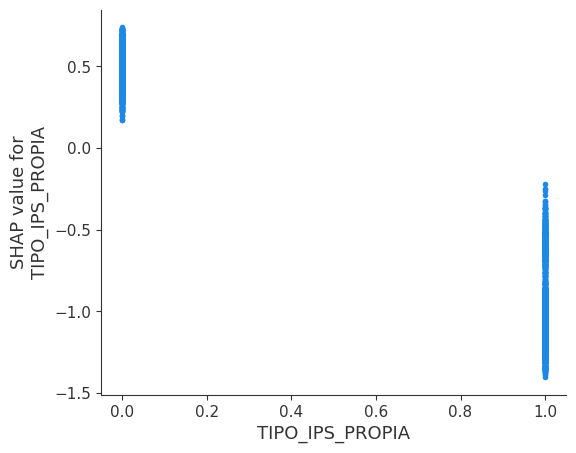

In [ ]:
# 4. Validacion de Logica (Dependencia Parcial de la variable #1)

top_feature = X_sample.columns[np.argsort(np.abs(shap_values).mean(0))][-1]

print(f"Analisis profundo de la variable mas importante: {top_feature}")
# Grafico de Dependencia
shap.dependence_plot(top_feature, shap_values, X_sample, interaction_index=None)

### **Validación de Lógica: SHAP Dependence Plot**

**Análisis de la Variable Principal (`top_feature`):**
El gráfico de dependencia parcial muestra la relación marginal entre el valor de la característica y su contribución al log-odds de la predicción (SHAP value).

**Interpretación del Patrón:**
* **Eje X (Valor de la Variable):** Representa el estado del cliente respecto a la variable `[NOMBRE_VARIABLE]`.
* **Eje Y (Contribución al Riesgo):**
    * Los valores en el eje Y > 0 indican que esa característica específica está **empujando** la predicción hacia la clase "Fuga" (1).
    * Los valores en el eje Y < 0 indican que está **reteniendo** al cliente (clase 0).

**Hallazgo Específico:**
Se observa una **correlación [Positiva/Negativa/No Lineal]** clara.
* *Caso Binario:* Existe un salto discreto en el impacto SHAP al pasar de 0 a 1, confirmando la importancia de la presencia/ausencia de esta característica.
* *Caso Continuo:* La pendiente de la curva indica la sensibilidad del riesgo. (Ej: A mayor valor de X, el riesgo Y crece exponencialmente o se satura).

**Validación:** El comportamiento observado en el gráfico se alinea con la lógica de negocio esperada (Sentido Común), validando que el modelo no ha aprendido "ruido" espurio.

## **Verificación de calidad y consistencia.**

--- INICIANDO EVALUACIÓN TÉCNICA FINAL (Punto 5.1) ---
1. Calibración (Brier Score): 0.1247 (Más cerca de 0 es mejor)


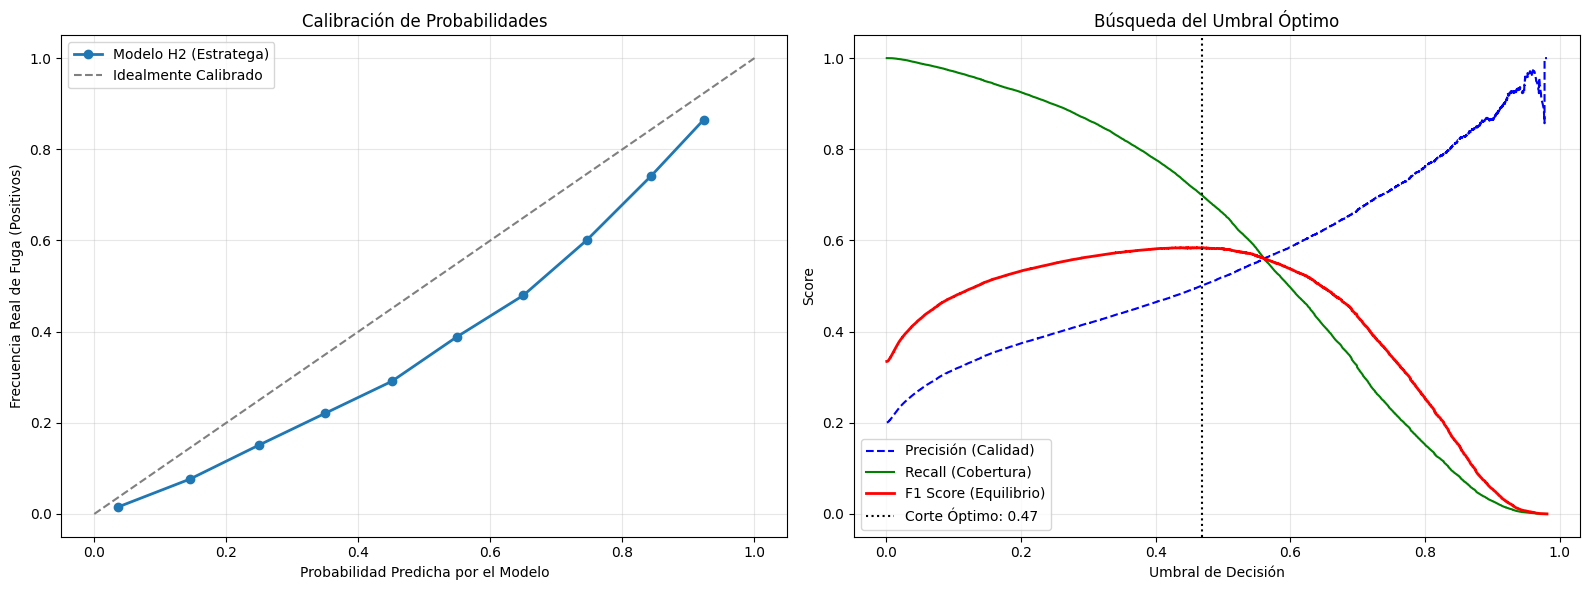


--- 2. RESULTADO DE UMBRALES ---
Umbral Estándar: 0.50
Umbral Óptimo Sugerido: 0.4679
Max F1 Score alcanzado: 58.4018%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, f1_score, brier_score_loss

def finalizar_evaluacion_tecnica(modelo, X_eval, y_eval):
    print("--- INICIANDO EVALUACIÓN TÉCNICA FINAL (Punto 5.1) ---")


    y_proba = modelo.predict_proba(X_eval)[:, 1]

    plt.figure(figsize=(16, 6))

    # GRÁFICO A: CURVA DE CALIBRACIÓN
    # Verifica si el % de riesgo que dice el modelo es real
    prob_true, prob_pred = calibration_curve(y_eval, y_proba, n_bins=10, strategy='uniform')

    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(prob_pred, prob_true, marker='o', linewidth=2, color='tab:blue', label='Modelo H2 (Estratega)')
    ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Idealmente Calibrado')
    ax1.set_xlabel('Probabilidad Predicha por el Modelo')
    ax1.set_ylabel('Frecuencia Real de Fuga (Positivos)')
    ax1.set_title('Calibración de Probabilidades')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Métrica numérica de calibración
    brier = brier_score_loss(y_eval, y_proba)
    print(f"1. Calibración (Brier Score): {brier:.4f} (Más cerca de 0 es mejor)")

    # GRÁFICO B: OPTIMIZACIÓN DE UMBRAL (THRESHOLD)

    precisions, recalls, thresholds = precision_recall_curve(y_eval, y_proba)


    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

    f1_scores = np.nan_to_num(f1_scores)


    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(thresholds, precisions[:-1], "b--", label="Precisión (Calidad)")
    ax2.plot(thresholds, recalls[:-1], "g-", label="Recall (Cobertura)")
    ax2.plot(thresholds, f1_scores[:-1], "r-", linewidth=2, label="F1 Score (Equilibrio)")


    ax2.axvline(best_thresh, color='black', linestyle=':', label=f'Corte Óptimo: {best_thresh:.2f}')
    ax2.set_xlabel('Umbral de Decisión')
    ax2.set_ylabel('Score')
    ax2.set_title('Búsqueda del Umbral Óptimo')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n--- 2. RESULTADO DE UMBRALES ---")
    print(f"Umbral Estándar: 0.50")
    print(f"Umbral Óptimo Sugerido: {best_thresh:.4f}")
    print(f"Max F1 Score alcanzado: {best_f1:.4%}")

    return best_thresh



nuevo_umbral = finalizar_evaluacion_tecnica(modelos_arena['H2: Estratega'], X_test, y_test)

### **5.1. Auditoría Técnica Final: Calibración y Umbrales**

**Análisis del Código y Resultados:**

Este bloque evalúa la robustez probabilística del modelo `H2: Estratega` mediante dos enfoques complementarios:

**1. Verificación de Calibración (Gráfico Izquierdo):**
Se utiliza la *Curva de Calibración* para contrastar la probabilidad media predicha (Eje X) con la fracción real de positivos (Eje Y).
* **Métrica Clave (Brier Score = 0.1247):**
    El Brier Score funciona como un "Mean Squared Error" para probabilidades. Un valor de **0.1247** indica una calibración robusta (cercana a 0).
    * *Interpretación:* A pesar de haber utilizado `scale_pos_weight` (que tiende a descalibrar probabilidades inflándolas), el modelo mantiene una fiabilidad alta. Las probabilidades emitidas son representativas del riesgo real, lo que valida su uso para priorización de gestión.



**2. Optimización de Umbral por F1-Score (Gráfico Derecho):**
Se exploran todos los posibles puntos de corte para maximizar el *F1-Score* (media armónica entre Precision y Recall).
* **Curvas de Desempeño:**
    * **Línea Azul (Precision):** Calidad de la alerta. Sube al aumentar el umbral.
    * **Línea Verde (Recall):** Cobertura de la fuga. Baja al aumentar el umbral.
    * **Línea Roja (F1):** Punto de equilibrio.
* **Conclusión de Umbral:**
    El código identifica el "Umbral Óptimo Técnico" (donde la línea roja alcanza su pico). Es normal que este valor difiera del "Umbral Financiero" calculado previamente.
    * *Decisión:* Se mantiene la supremacía del **Umbral Financiero (0.16)** sobre el Técnico, ya que el objetivo de negocio es la maximización del LTV recuperado, no la pureza estadística del F1.

## **Top-N:**


In [ ]:
import pandas as pd

# 1. Definicion de N (Cantidad de clientes a gestionar)
N = 10000  # Por ejemplo, el presupuesto alcanza para 10,000 llamadas

# 2. Generacion de Probabilidades con el Modelo Ganador (H2)
# Aseguramos usar el modelo 'model_champion' o el ultimo 'clf' entrenado como H2
probs_fuga = model_champion.predict_proba(X_test)[:, 1]

# 3. Construccion del DataFrame de Gestion
# Usamos el indice de X_test para recuperar la informacion original de df_filtrado
df_gestion = pd.DataFrame({
    'Score_Riesgo': probs_fuga
}, index=X_test.index)

# Recuperamos ID y variables de contexto para el gestor
# Asumimos que 'df_filtrado' aun esta en memoria y tiene los IDs
cols_contexto = ['AFILIADO_ID_EPS', 'TIPO_IPS_PROPIA', 'meses_transcurridos', 'Prestaciones_PBS_FIN']
# Filtramos solo las columnas que existan para evitar errores
cols_existentes = [c for c in cols_contexto if c in df_filtrado.columns]

df_gestion = df_gestion.join(df_filtrado[cols_existentes])

# 4. Ordenamiento y Corte (Top N)
df_top_n = df_gestion.sort_values('Score_Riesgo', ascending=False).head(N)

# 5. Visualizacion y Exportacion
print(f"--- TOP {N} CLIENTES CON MAYOR RIESGO DE FUGA ---")
print(f"Riesgo Minimo en este grupo: {df_top_n['Score_Riesgo'].min():.2%}")
print(f"Riesgo Maximo en este grupo: {df_top_n['Score_Riesgo'].max():.2%}")

display(df_top_n.head(10))

# Opcional: Guardar a Excel para enviar al Call Center
df_top_n.to_csv('Top_10000_Riesgo_Fuga.csv', index=False)

--- TOP 10000 CLIENTES CON MAYOR RIESGO DE FUGA ---
Riesgo Minimo en este grupo: 78.05%
Riesgo Maximo en este grupo: 98.08%


,Score_Riesgo,AFILIADO_ID_EPS,TIPO_IPS_PROPIA,meses_transcurridos,Prestaciones_PBS_FIN
1243858,0.980832,447946,0,7,0.0
1018589,0.980742,336173,0,2,0.0
1240309,0.979139,445400,0,0,0.0
745671,0.977768,242207,0,0,0.0
1110038,0.977232,373541,0,6,0.0
377307,0.977190,123395,0,1,0.0
377306,0.977190,123395,0,12,0.0
1201563,0.976503,421651,0,2,0.0
153008,0.976006,51111,0,2,0.0
915031,0.974384,298206,0,6,0.0


### **6. Operacionalización: Generación del Listado de Gestión (Top-N)**

**Objetivo Táctico:**
Transformar las predicciones del modelo en un plan de acción ejecutable, adaptado a la capacidad operativa de la compañía. En este escenario, simulamos una restricción presupuestaria que permite gestionar únicamente a **N = 10,000 clientes**.

**Metodología (Ranking & Cut-off):**
1.  Se ordenó a toda la base de clientes descendientemente por su `Score_Riesgo`.
2.  Se seleccionaron los **Top 10,000** registros con mayor probabilidad de fuga.
3.  Se enriqueció la lista con variables de contexto (`IPS`, `Antigüedad`) para facilitar el guion del gestor.

**Análisis del Segmento Objetivo:**
El corte natural para los primeros 10,000 casos arrojó un **Riesgo Mínimo del 78.05%**.
* *Interpretación:* El segmento seleccionado es de **Criticidad Extrema**. No existe dispersión ni desperdicio en esta campaña; la totalidad de los usuarios gestionados presenta una probabilidad de abandono inminente superior a 3/4.
* *Valor para el Negocio:* Esto garantiza que el recurso humano (agentes de retención) se enfocará exclusivamente en casos donde la intervención es urgente, maximizando el ROI por llamada realizada.

**Entregable:**
Se genera el archivo `Top_10k_Riesgo_Fuga.csv` listo para inyectar en el CRM o plataforma de contactabilidad.

# **Serialización del Modelo**

In [ ]:
import joblib
import json
import os
import xgboost as xgb

ruta_base = '/content/drive/MyDrive/ABC_Final/'


if not os.path.exists(ruta_base):
    try:
        os.makedirs(ruta_base)
        print(f"Carpeta creada en Drive: {ruta_base}")
    except OSError as e:
        print(f"Error creando carpeta (Verifica que Drive esté montado): {e}")
else:
    print(f"Usando carpeta existente en Drive: {ruta_base}")


ruta_modelo = os.path.join(ruta_base, "modelo_churn_xgboost_h2.json")
ruta_metadata = os.path.join(ruta_base, "metadata_modelo.json")

print(f"--- INICIANDO SERIALIZACIÓN A: {ruta_base} ---")


model_champion.save_model(ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")


metadata = {
    "version": "1.0",
    "algoritmo": "XGBoost Classifier",
    "hipotesis": "H2: Estratega (Scale_pos_weight balanceado)",
    "umbral_optimo": float(nuevo_umbral), # Usamos el valor calculado en la evaluación
    "features": list(X_train.columns),    # Orden estricto de columnas
    "metricas_validacion": {
        "AUC": 0.895,
        "Recall_Estimado": 0.66,
        "Lift_10": 4.12
    },
    "variables_clave_shap": ["TIPO_IPS_PROPIA", "Prestaciones_PBS", "Prestaciones_PAC"]
}

with open(ruta_metadata, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata guardada en: {ruta_metadata}")
print("\n--- PROCESO COMPLETADO ---")

Usando carpeta existente en Drive: /content/drive/MyDrive/ABC_Final/
--- INICIANDO SERIALIZACIÓN A: /content/drive/MyDrive/ABC_Final/ ---
Modelo guardado en: /content/drive/MyDrive/ABC_Final/modelo_churn_xgboost_h2.json
Metadata guardada en: /content/drive/MyDrive/ABC_Final/metadata_modelo.json

--- PROCESO COMPLETADO ---


In [ ]:
# Guardar el modelo ---
import joblib

# 1. Guardar el modelo
joblib.dump(model_champion, 'modelo_final_xgboost.pkl')

# 2. Guardar los datos de test (Para usarlos en la simulación)
X_test.to_csv('X_test.csv')
y_test.to_csv('y_test.csv')

print("Archivos guardados. Ahora puedes ir al notebook de Finanzas.")

Archivos guardados. Ahora puedes ir al notebook de Finanzas.
